# 09 Thermal network + extra atomic BOP (IA-THM/AIR/FLD/HEX)

**Requirement:** `IA-THM-001`

Patents: US12308414B2, EP4602674A1. Equations are paraphrased; see claims/paragraphs cited below.

## Governing equations

Lumped energy balance on electrode, electrolyte, vessel wall, lid, and cavity coolant
(US FIGS. 1E-1F, 9A), with $T$ in $\mathrm{K}$ and heat rates in $\mathrm{W}$:

$$m c_p \frac{\mathrm{d}T}{\mathrm{d}t} = \sum q$$

Extra atomic pieces live here as importable modules:
`AirSystem`, `Fan`, `ElectrolyteFlow`, `Pump`, `Reservoir`, `Valve`, `Pipe`, `HeatExchanger`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

here = Path.cwd()
for cand in (here, here.parent):
    if (cand / "src" / "ironair").is_dir() and (cand / "plant_sim").is_dir():
        sys.path.insert(0, str(cand))
        sys.path.insert(0, str(cand / "src"))
        break

from plant_sim.bootstrap import setup_path

setup_path()
from plant_sim.params import CAPACITY_FE_OH2_MAH_G, CAPACITY_MAGNETITE_MAH_G, default_params

In [2]:
from IPython import get_ipython

_ipy = get_ipython()
if _ipy is not None:
    _ipy.run_line_magic("matplotlib", "inline")

sns.set(
    rc={
        "axes.labelsize": 12,
        "axes.titlesize": 18,
        "figure.figsize": (11, 8.5),
        "figure.dpi": 300,
        "figure.facecolor": "w",
        "figure.edgecolor": "k",
    }
)
P = default_params()
print("KOH default", P.c_KOH_mol_m3 / 1000, "M; T_ep", P.T_ep_sim_K, "K")
print("Faraday 960/320 checks", round(CAPACITY_FE_OH2_MAH_G, 2), round(CAPACITY_MAGNETITE_MAH_G, 2))

KOH default 6.0 M; T_ep 303.15 K
Faraday 960/320 checks 959.85 319.95


## Simulation setup

Integrate the model once. Plot sections below each document what is shown, why it matters for patent/requirement verification, and the equations that govern that view.


In [3]:
from plant_sim.components.thermal import ThermalNetwork
from plant_sim.components.air_system import AirSystem, Fan
from plant_sim.components.hydraulics import Pump, Valve
from plant_sim.components.base import integrate_component

th = ThermalNetwork(P)
t, y = integrate_component(
    lambda t, y: th.rhs(
        t, y, {"q_reaction_W": 20.0, "q_joule_W": 5.0, "T_amb_K": P.T_ref_K, "mdot_coolant_kg_s": 0.04}, {}
    ),
    th.y0(),
    (0, 1200),
    n_eval=120,
)

## Thermal network node temperatures

### What this plot illustrates

Lumped thermal nodes (electrode, electrolyte, vessel, lid/coolant) responding to $I\eta$ heat and ambient exchange.

### Governing equations

$$C_i \dot T_i = \dot Q_{\mathrm{gen},i} + \sum_j UA_{ij}(T_j-T_i) + UA_{i,\infty}(T_\infty-T_i)$$


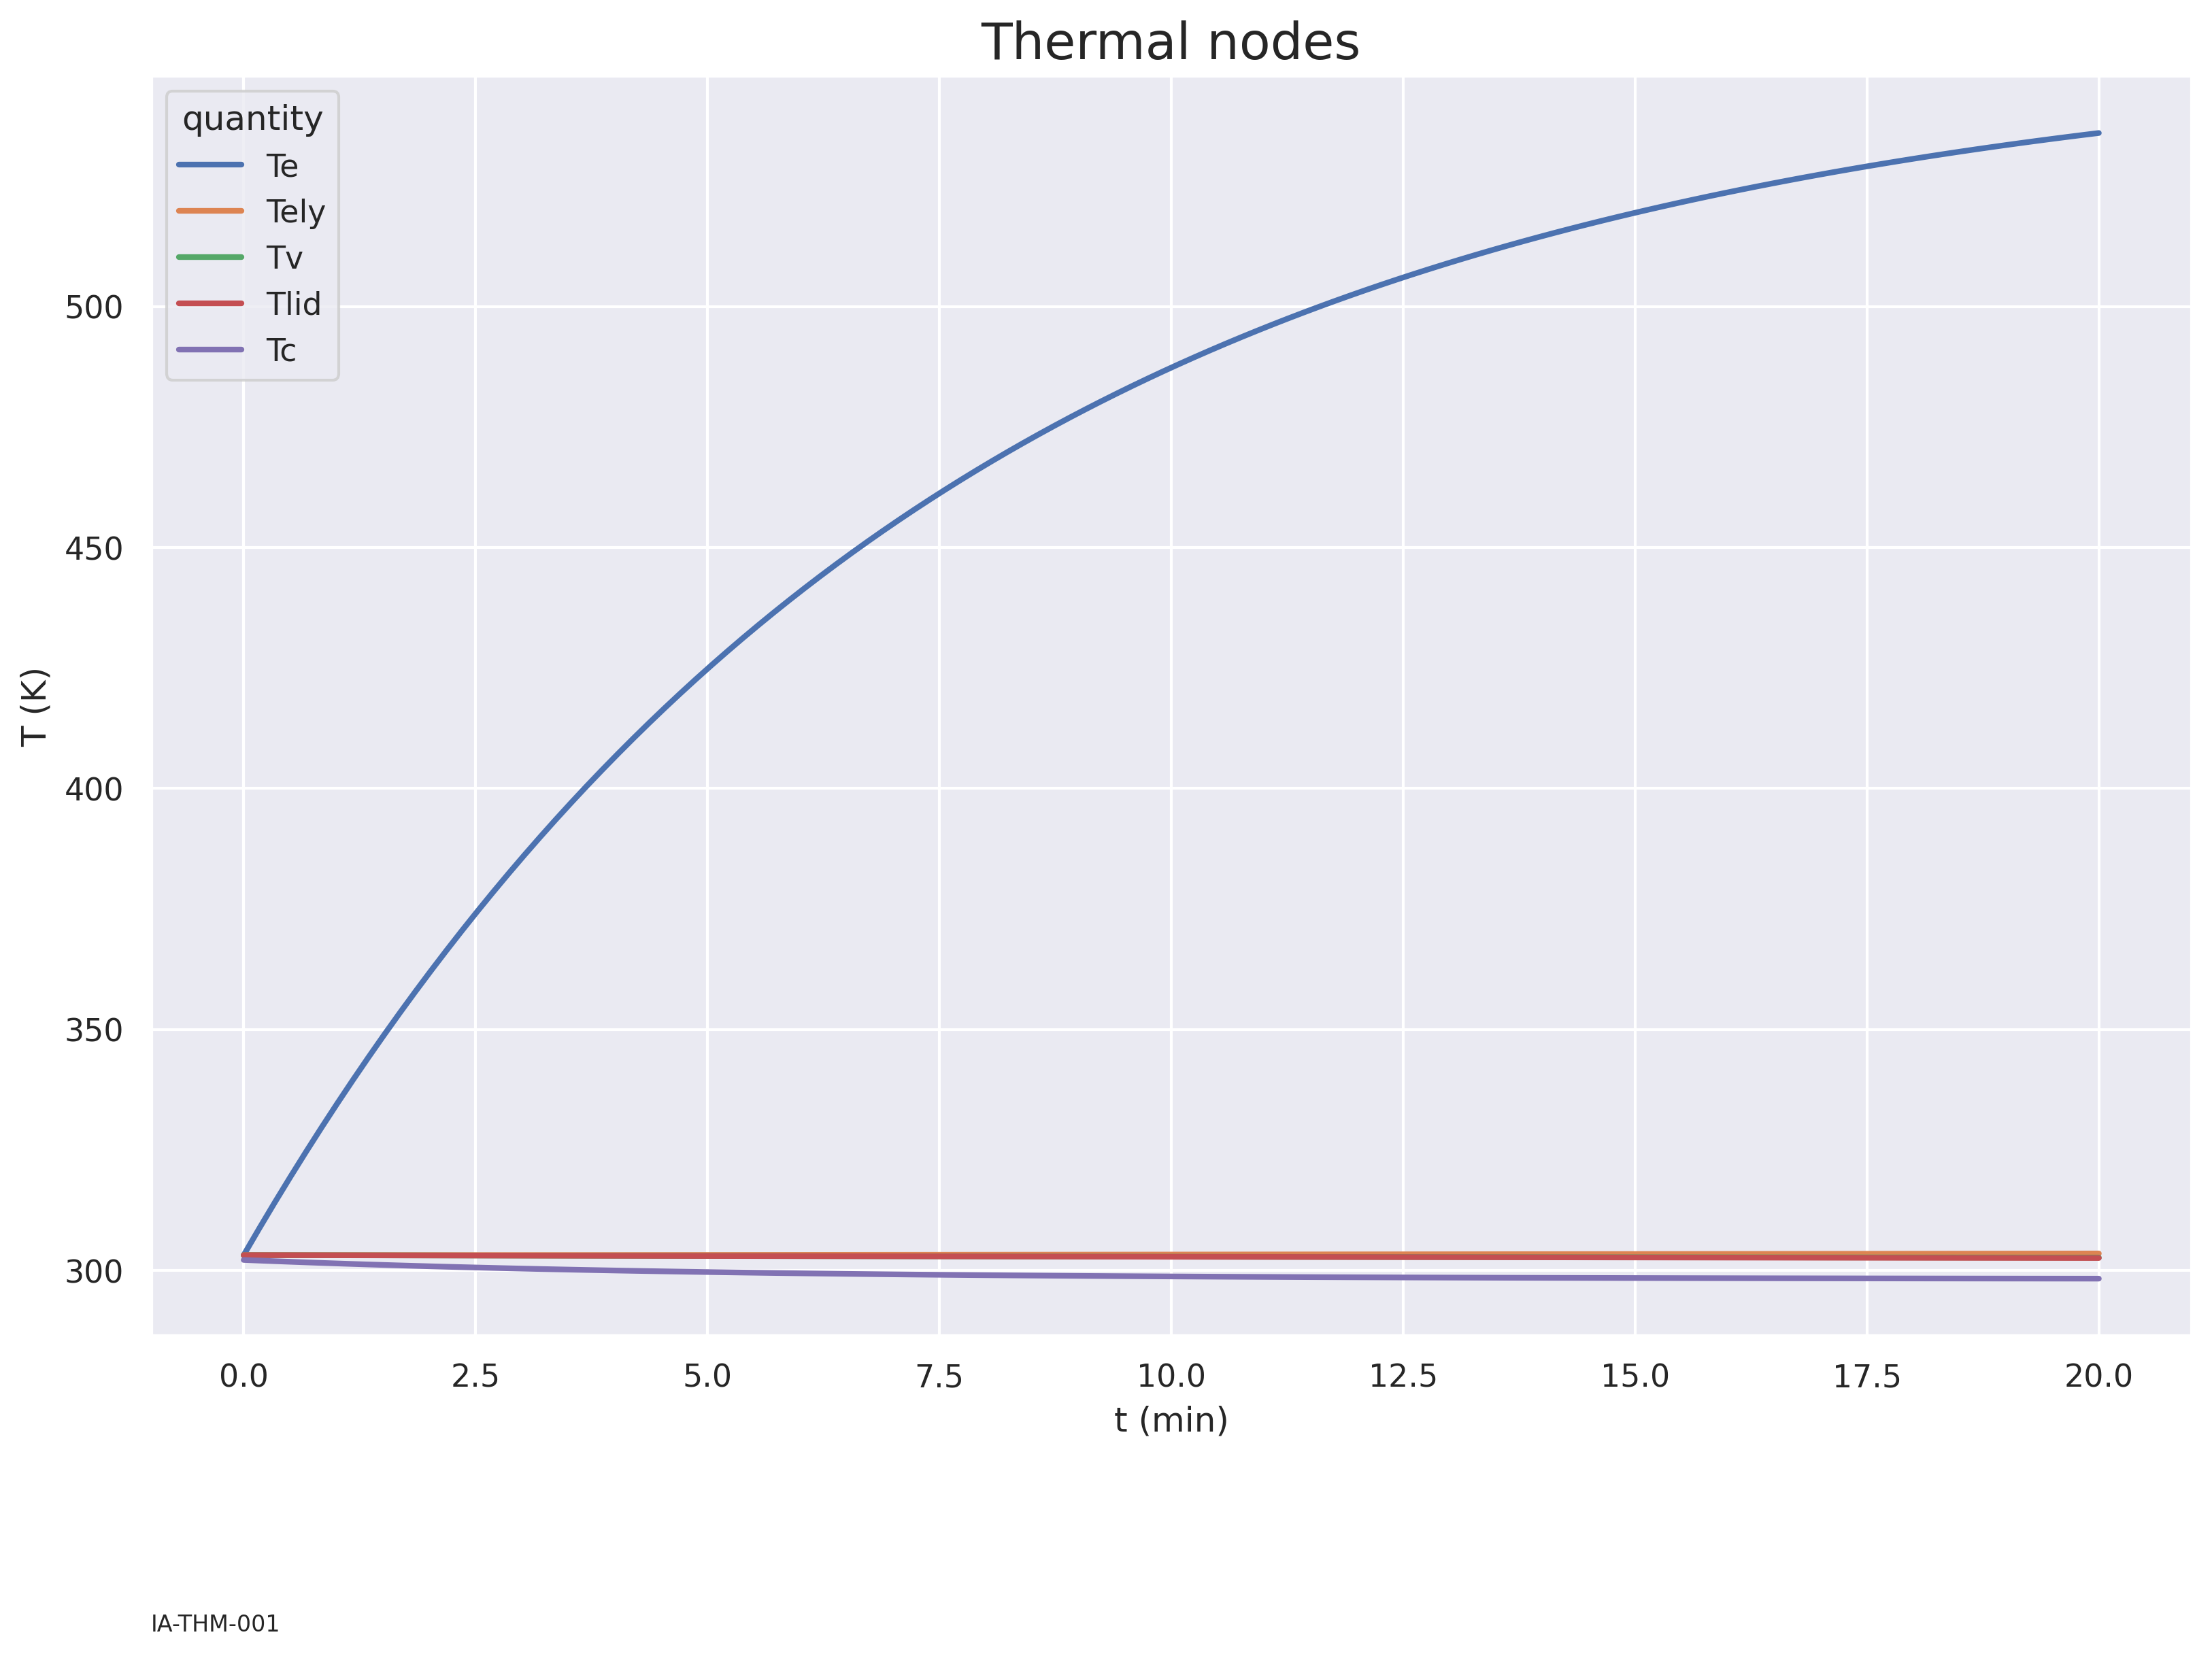

In [4]:
plot_frame = pd.DataFrame(
    {
        "t": (t / 60),
        "Te": (y[0]),
        "Tely": (y[1]),
        "Tv": (y[2]),
        "Tlid": (y[3]),
        "Tc": (y[4]),
    }
)
plot_long = plot_frame.melt(id_vars="t", var_name="quantity", value_name="value")
fig, ax = plt.subplots()
sns.lineplot(data=plot_long, x="t", y="value", hue="quantity", ax=ax, linewidth=2.0)
ax.set_xlabel("t (min)")
ax.set_ylabel("T (K)")
ax.set_title("Thermal nodes")
ax.text(0.0, -0.22, "IA-THM-001", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## Numerical checks

Finite-trajectory and capacity checks for the integration above.


In [5]:
for label, obj, uu in [
    ("air", AirSystem(P), {"mdot_air_kg_s": 0.002, "r_orr_mol_s": 1e-6, "T_K": P.T_ep_sim_K}),
    ("fan", Fan(P), {"I_fan_A": 1.0}),
    ("pump", Pump(P), {"I_pump_A": 1.5}),
    ("valve", Valve(P), {"valve_cmd": 1.0, "dP_Pa": 2e4}),
]:
    tt, yy = integrate_component(lambda t, y, o=obj, u=uu: o.rhs(t, y, u, {}), obj.y0(), (0, 15), n_eval=30)
    print(label, "finite", np.all(np.isfinite(yy)))

air finite True
fan finite True
pump finite True
valve finite True


## Verification against patents / SSS002

In [6]:
print("Adiabatic node with +q raises T (IA-THM-001 comment). Extra atomic modules imported above.")

Adiabatic node with +q raises T (IA-THM-001 comment). Extra atomic modules imported above.
